# REMD MBAR Free Energy Analysis

This notebook performs free energy surface (FES) analysis using the MBAR method.

In [1]:
"""
REMD MBAR FES Analysis Notebook
"""

import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from pathlib import Path

# Import FESAnalyzer from CTGoMartini
from ctgomartini.analysis.remd_mbar import FESAnalyzer

# Set plotting style with Arial font
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

print('Imports successful!')

Imports successful!


## 1. Setup and Configuration

Define input files and analysis parameters.

In [2]:
# Configuration

OUTPUT_FILE = 'output.nc'
CV_FILE = './dRMStraj_nc_StateB.dat'  # or StateA
INTERVAL = 5  # CV data interval


# Analysis parameters
ANALYSIS_PARAMS = {
    'g': 1,                    # Statistical inefficiency
    'length_ratio': 1.0,       # Use full trajectory
    'start_point': None,       # Start from specific frame
    'start_ratio': 0.2,        # Skip first 20% for equilibration
    'selected_state': 5        # Thermodynamic state to analyze
}

LEFT_BOUND = 3
RIGHT_BOUND = 8

# FES calculation CV range
# Set to None for automatic range (5% padding on each side)
# Or set manually, e.g., FES_RANGES = [1.5, 11]
FES_RANGES = [1.5, 11]

# Output directories
os.makedirs('AnalysisParameter', exist_ok=True)
os.makedirs('FitEnergy', exist_ok=True)

print(f'Output file: {OUTPUT_FILE}')
print(f'CV file: {CV_FILE}')
print(f'Barrier search bounds: [{LEFT_BOUND}, {RIGHT_BOUND}]')
print(f'FES ranges: {FES_RANGES if FES_RANGES else "Auto (5% padding)"}')

Output file: output.nc
CV file: ./dRMStraj_nc_StateB.dat
Barrier search bounds: [3, 8]
FES ranges: [1.5, 11]


## 2. Initialize Analyzer

Load simulation data and initialize FES analyzer.

In [3]:
# Initialize analyzer
analyzer = FESAnalyzer(OUTPUT_FILE, CV_FILE, interval=INTERVAL)

print(f'Number of states: {analyzer.n_states}')
print(f'Temperatures: {analyzer.temperatures_k}')
print(f'CV shape: {analyzer.cv_values_replica.shape}')

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.



****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************

Could not locate checkpoint subfile. This is okay for analysis if the solvent trajectory is not needed, but not for production simulation!


Number of states: 11
Temperatures: [310. 310. 310. 310. 310. 310. 310. 310. 310. 310. 310.]
CV shape: (11, 80001)


## 3. Single State Analysis

Analyze free energy surface for a single state.

In [4]:
# Initialize FES
analyzer.initialize_fes(
    g=ANALYSIS_PARAMS['g'],
    length_ratio=ANALYSIS_PARAMS['length_ratio'],
    start_ratio=ANALYSIS_PARAMS['start_ratio']
)

# Analyze single state
print(f"CV range in data: [{analyzer.concatenated_cv.min():.2f}, {analyzer.concatenated_cv.max():.2f}]")
print(f"Using FES_RANGES: {FES_RANGES}")
print(f"Barrier search bounds: [{LEFT_BOUND}, {RIGHT_BOUND}]")

results = analyzer.analyze_onestate(
    selected_state=ANALYSIS_PARAMS['selected_state'],
    ranges=FES_RANGES,
    left_bound=LEFT_BOUND,
    right_bound=RIGHT_BOUND
)

print('\nMetrics:')
for key, value in results['metrics'].items():
    if isinstance(value, float):
        print(f'  {key}: {value:.4f}')
    else:
        print(f'  {key}: {value}')

# Check if metrics failed
if np.isnan(results['metrics']['barrier']):
    print("\n⚠️  WARNING: Metrics calculation failed (all NaN)")
    print("   Possible causes:")
    print("   1. left_bound/right_bound outside CV data range")
    print("   2. FES_RANGES too narrow or outside data range")
    print(f"   3. No data points between [{LEFT_BOUND}, {RIGHT_BOUND}]")
    print(f"\n   Try: FES_RANGES = None  # for auto-range")
    print(f"   Or adjust: LEFT_BOUND/RIGHT_BOUND to match CV data range")


******* JAX 64-bit mode is now on! *******
*     JAX is now set to 64-bit mode!     *
*   This MAY cause problems with other   *
*      uses of JAX in the same code.     *
******************************************



CV range in data: [1.08, 13.48]
Using FES_RANGES: [1.5, 11]
Barrier search bounds: [3, 8]

Metrics:
  barrier_pos: 3.7325
  barrier: 8.5276
  basin1_pos: 1.9275
  basin2_pos: 9.2425
  basin1_fes: 0.0000
  basin2_fes: 6.1314
  keq: 1.6887


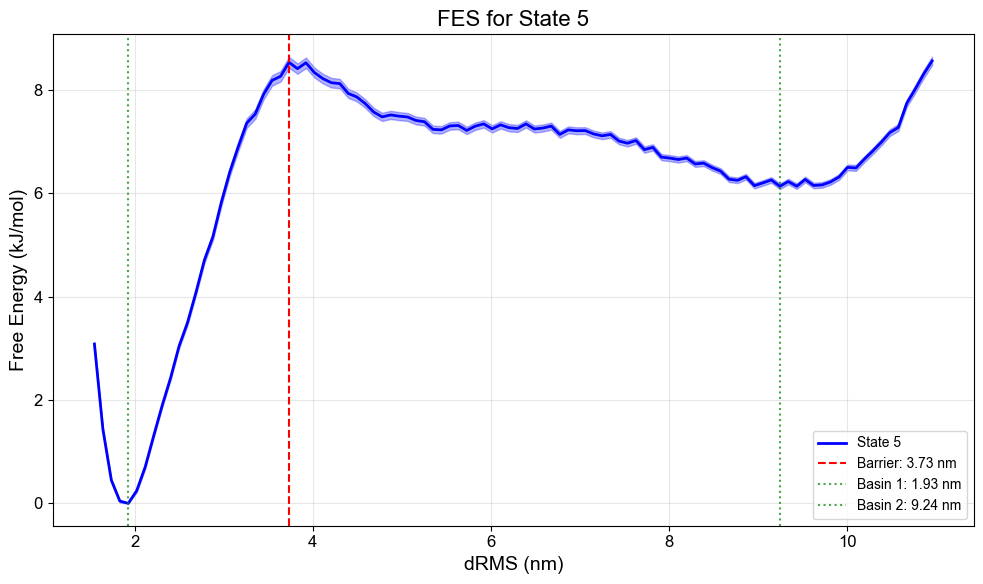

Barrier: 8.53 kJ/mol
Keq: 1.6887


In [5]:
# Plot FES
fig, ax = plt.subplots(figsize=(10, 6))

cv_values = results['cv_values']
fes = results['fes']
fes_uncertainty = results['fes_uncertainty']
metrics = results['metrics']

ax.plot(cv_values, fes, 'b-', linewidth=2, label=f"State {ANALYSIS_PARAMS['selected_state']}")
ax.fill_between(cv_values, 
                fes - fes_uncertainty, 
                fes + fes_uncertainty, 
                alpha=0.3, color='b')

ax.axvline(metrics['barrier_pos'], color='r', linestyle='--', label=f"Barrier: {metrics['barrier_pos']:.2f} nm")
ax.axvline(metrics['basin1_pos'], color='g', linestyle=':', alpha=0.7, label=f"Basin 1: {metrics['basin1_pos']:.2f} nm")
ax.axvline(metrics['basin2_pos'], color='g', linestyle=':', alpha=0.7, label=f"Basin 2: {metrics['basin2_pos']:.2f} nm")

ax.set_xlabel('dRMS (nm)', fontsize=14)
ax.set_ylabel('Free Energy (kJ/mol)', fontsize=14)
ax.set_title(f'FES for State {ANALYSIS_PARAMS["selected_state"]}', fontsize=16)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'AnalysisParameter/fes_state_{ANALYSIS_PARAMS["selected_state"]}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Barrier: {metrics['barrier']:.2f} kJ/mol")
print(f"Keq: {metrics['keq']:.4f}")
# print(f"Saved: AnalysisParameter/fes_state_{ANALYSIS_PARAMS['selected_state']}.png")

## 4. Parameter Sweep Analysis

Check convergence and sensitivity.

In [6]:
# Start ratio sweep
print('Start ratio sweep...')
start_ratio_results = analyzer.parameter_sweep(
    'start_ratio', 
    [0, 0.1, 0.2, 0.3, 0.4, 0.5],
    default_params=ANALYSIS_PARAMS,
    ranges=FES_RANGES,
    left_bound=LEFT_BOUND,
    right_bound=RIGHT_BOUND
)
analyzer.save_results(start_ratio_results, 'AnalysisParameter/start_ratio_results.pkl')

print('Statistical inefficiency sweep...')
g_values_results = analyzer.parameter_sweep(
    'g', 
    [1, 5, 10, 20, 50],
    default_params=ANALYSIS_PARAMS,
    ranges=FES_RANGES,
    left_bound=LEFT_BOUND,
    right_bound=RIGHT_BOUND
)
analyzer.save_results(g_values_results, 'AnalysisParameter/g_values_results.pkl')

print('Length ratio sweep...')
length_ratio_results = analyzer.parameter_sweep(
    'length_ratio', 
    [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    default_params=ANALYSIS_PARAMS,
    ranges=FES_RANGES,
    left_bound=LEFT_BOUND,
    right_bound=RIGHT_BOUND
)
analyzer.save_results(length_ratio_results, 'AnalysisParameter/length_ratio_results.pkl')

print('State sweep...')
state_results = analyzer.parameter_sweep(
    'selected_state', 
    list(range(analyzer.n_states)),
    default_params=ANALYSIS_PARAMS,
    ranges=FES_RANGES,
    left_bound=LEFT_BOUND,
    right_bound=RIGHT_BOUND
)
analyzer.save_results(state_results, 'AnalysisParameter/selected_state_results.pkl')

print('All sweeps completed!')

Start ratio sweep...
start_ratio=0: {'barrier_pos': 3.9225000000000003, 'barrier': 7.980023990531178, 'basin1_pos': 1.9275, 'basin2_pos': 9.622499999999999, 'basin1_fes': 0.0, 'basin2_fes': 4.975469431949344, 'keq': 1.2219681616364317}
start_ratio=0.1: {'barrier_pos': 3.9225000000000003, 'barrier': 8.552063188550273, 'basin1_pos': 1.9275, 'basin2_pos': 8.9575, 'basin1_fes': 0.0, 'basin2_fes': 5.991749741504848, 'keq': 1.6821371000276786}
start_ratio=0.2: {'barrier_pos': 3.7325, 'barrier': 8.52758303468691, 'basin1_pos': 1.9275, 'basin2_pos': 9.2425, 'basin1_fes': 0.0, 'basin2_fes': 6.131379733395184, 'keq': 1.6887443066782715}
start_ratio=0.3: {'barrier_pos': 3.7325, 'barrier': 8.639924278912913, 'basin1_pos': 1.9275, 'basin2_pos': 9.2425, 'basin1_fes': 0.0, 'basin2_fes': 6.081617939984619, 'keq': 1.7104845919321348}
start_ratio=0.4: {'barrier_pos': 3.7325, 'barrier': 8.277451652509281, 'basin1_pos': 1.8325, 'basin2_pos': 8.9575, 'basin1_fes': 0.0, 'basin2_fes': 5.5206117750503605, 'ke

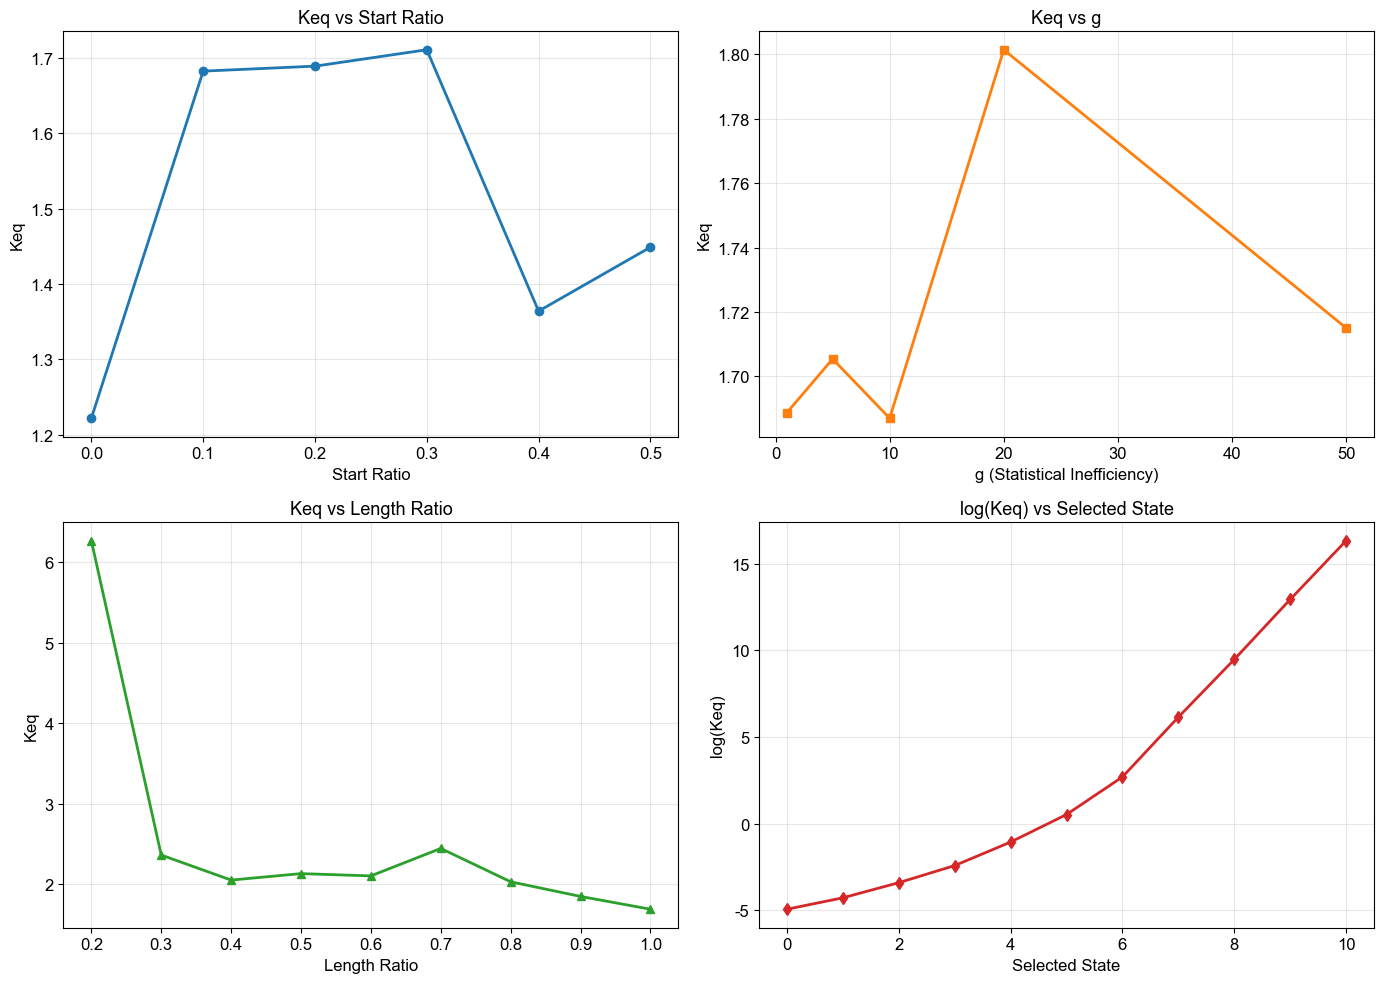

Saved: AnalysisParameter/parameter_sweep_keq.png


In [7]:
# Plot parameter sweeps (Keq only)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Start ratio sweep
ratios = list(start_ratio_results.keys())
keqs = [start_ratio_results[r]['metrics']['keq'] for r in ratios]
axes[0,0].plot(ratios, keqs, 'o-', linewidth=2, color='C0')
axes[0,0].set_xlabel('Start Ratio', fontsize=12)
axes[0,0].set_ylabel('Keq', fontsize=12)
axes[0,0].set_title('Keq vs Start Ratio', fontsize=13)
axes[0,0].grid(True, alpha=0.3)

# g value sweep
g_values = list(g_values_results.keys())
keqs = [g_values_results[g]['metrics']['keq'] for g in g_values]
axes[0,1].plot(g_values, keqs, 's-', linewidth=2, color='C1')
axes[0,1].set_xlabel('g (Statistical Inefficiency)', fontsize=12)
axes[0,1].set_ylabel('Keq', fontsize=12)
axes[0,1].set_title('Keq vs g', fontsize=13)
axes[0,1].grid(True, alpha=0.3)

# Length ratio sweep
lengths = list(length_ratio_results.keys())
keqs = [length_ratio_results[l]['metrics']['keq'] for l in lengths]
axes[1,0].plot(lengths, keqs, '^-', linewidth=2, color='C2')
axes[1,0].set_xlabel('Length Ratio', fontsize=12)
axes[1,0].set_ylabel('Keq', fontsize=12)
axes[1,0].set_title('Keq vs Length Ratio', fontsize=13)
axes[1,0].grid(True, alpha=0.3)

# Selected state sweep
states = list(state_results.keys())
keqs = [state_results[s]['metrics']['keq'] for s in states]
axes[1,1].plot(states, np.log(keqs), 'd-', linewidth=2, color='C3')
axes[1,1].set_xlabel('Selected State', fontsize=12)
axes[1,1].set_ylabel('log(Keq)', fontsize=12)
axes[1,1].set_title('log(Keq) vs Selected State', fontsize=13)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('AnalysisParameter/parameter_sweep_keq.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: AnalysisParameter/parameter_sweep_keq.png")

## 5. Mixed-State Analysis (EXP and HAM)


In [28]:
# EXP Mixing
# Re-initialize FES with current parameters
analyzer.initialize_fes(
    g=1,
    length_ratio=1.0,
    start_ratio=0.2
)

exp_params = {
    'beta': 1/300,
    'C1': -300,
    'C2': 0
}

exp_results = analyzer.analyze_one_mixing_parameters(
    mixing_parameters=exp_params,
    temperature=310,
    method='EXP',
    ranges=[1.4,13],
    left_bound=LEFT_BOUND,
    right_bound=RIGHT_BOUND
)

exp_results['mixing_parameters'] = exp_params
exp_results['temperature'] = 310
exp_results['method'] = 'EXP'

analyzer.save_results(exp_results, 'FitEnergy/FreeEnergy_EXP.pkl')
print('EXP:', exp_results['metrics'])

EXP: {'barrier_pos': 3.7779999999999996, 'barrier': 6.503258043478568, 'basin1_pos': 1.922, 'basin2_pos': 8.998, 'basin1_fes': 0.0, 'basin2_fes': 3.469069218682739, 'keq': 0.6998263517738478}


In [26]:
# HAM Mixing
# Re-initialize FES with current parameters
analyzer.initialize_fes(
    g=ANALYSIS_PARAMS['g'],
    length_ratio=ANALYSIS_PARAMS['length_ratio'],
    start_point=ANALYSIS_PARAMS['start_point'],
    start_ratio=ANALYSIS_PARAMS['start_ratio']
)

ham_params = {
    'delta': 350,
    'C1': -348,
    'C2': 0
}

ham_results = analyzer.analyze_one_mixing_parameters(
    mixing_parameters=ham_params,
    temperature=310,
    method='HAM',
    ranges=[1.4,13],
    left_bound=LEFT_BOUND,
    right_bound=RIGHT_BOUND
)

ham_results['mixing_parameters'] = ham_params
ham_results['temperature'] = 310
ham_results['method'] = 'HAM'

analyzer.save_results(ham_results, 'FitEnergy/FreeEnergy_HAM.pkl')
print('HAM:', ham_results['metrics'])

HAM: {'barrier_pos': 3.7779999999999996, 'barrier': 6.14510656237571, 'basin1_pos': 2.0380000000000003, 'basin2_pos': 8.998, 'basin1_fes': 0.0, 'basin2_fes': 3.5036785516251014, 'keq': 0.7227741032522699}


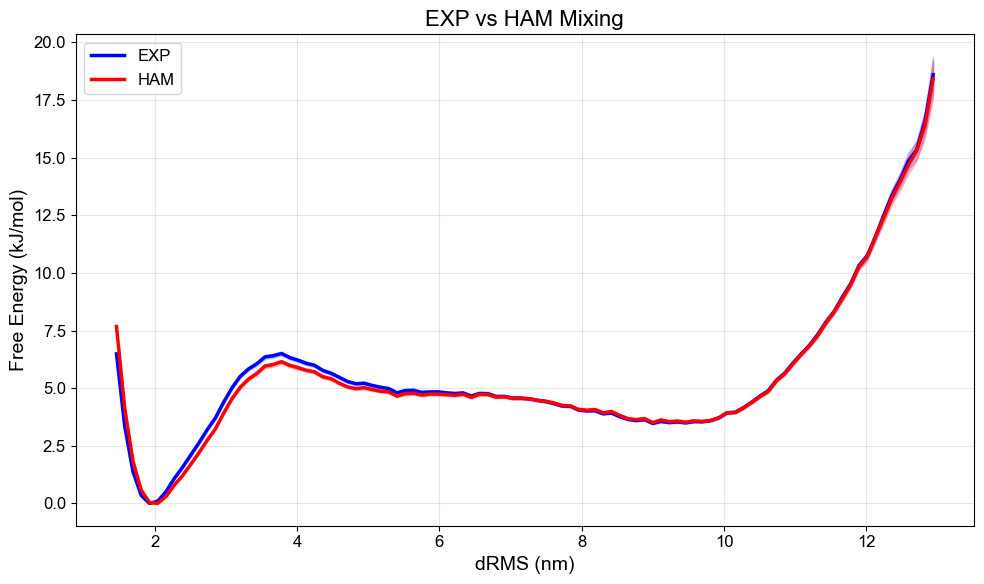


EXP: Barrier=6.50 kJ/mol, Keq=0.6998
HAM: Barrier=6.15 kJ/mol, Keq=0.7228
Saved: FitEnergy/exp_vs_ham.png


In [29]:
# Compare EXP and HAM
fig, ax = plt.subplots(figsize=(10, 6))

exp_fes = exp_results['fes']
ax.plot(exp_results['cv_values'], exp_fes, 'b-', linewidth=2.5, label='EXP')
ax.fill_between(exp_results['cv_values'],
                exp_fes - exp_results['fes_uncertainty'],
                exp_fes + exp_results['fes_uncertainty'],
                alpha=0.2, color='b')

ham_fes = ham_results['fes']
ax.plot(ham_results['cv_values'], ham_fes, 'r-', linewidth=2.5, label='HAM')
ax.fill_between(ham_results['cv_values'],
                ham_fes - ham_results['fes_uncertainty'],
                ham_fes + ham_results['fes_uncertainty'],
                alpha=0.2, color='r')

ax.set_xlabel('dRMS (nm)', fontsize=14)
ax.set_ylabel('Free Energy (kJ/mol)', fontsize=14)
ax.set_title('EXP vs HAM Mixing', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('FitEnergy/exp_vs_ham.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nEXP: Barrier={exp_results['metrics']['barrier']:.2f} kJ/mol, Keq={exp_results['metrics']['keq']:.4f}")
print(f"HAM: Barrier={ham_results['metrics']['barrier']:.2f} kJ/mol, Keq={ham_results['metrics']['keq']:.4f}")
print("Saved: FitEnergy/exp_vs_ham.png")